# The Chaikin Oscillator — a quantitative teardown 🔬
### Mechanical EMA3−EMA10 A/D-momentum on 5 indices · cross-above-zero forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-MFM geometry placebo · costs · a synthetic planted-lead control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A/D_leads_price%3F: Busted](https://img.shields.io/badge/A%2FD_leads_price%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **oscillator** from the **drift**: an upward-trending index makes *any* momentum-buy look good, so the only meaningful test is cross-vs-random, plus a placebo that destroys the A/D information while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. The shared cache stores OHLC only, so the A/D line is fed a **deterministic, look-ahead-free** range-based volume proxy; the oscillator is the standard EMA(3)−EMA(10), causal throughout; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chaikin_oscillator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real chaikin cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1452, 'fast': 3, 'slow': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 1452, 22.4, 57, 3.03, 28.3, -5.9, 20.4, -0.56, 0.575), 'h10': (10, 1451, 41.0, 60, 3.63, 63.2, -22.3, 39.0, -1.65, 0.099), 'h20': (20, 1449, 96.0, 63, 4.88, 117.9, -21.9, 94.0, -1.14, 0.254), 'h60': (60, 1444, 278.6, 67, 5.81, 348.4, -69.8, 276.6, -2.14, 0.032), 'per': [('SPY', 272, 80.4, 2.03, 131.1, -50.7), ('QQQ', 270, 137.3, 3.17, 129.4, 7.9), ('IWM', 322, 112.3, 2.28, 120.6, -8.3), ('DIA', 289, 49.9, 1.31, 102.6, -52.6), ('GLD', 299, 99.4, 2.71, 107.4, -8.0)], 'placebo': (80.4, 0.703, 500), 'syn': [(0.0, 222, -14.0, 48, -0.37), (0.15, 136, 538.7, 88, 16.31)]}


real chaikin cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Cross-above-zero vs a **drift-matched random** baseline: the cross is *worse* at every horizon (Δ = -6/-22/-22/-70 bps) and the cross-minus-random Welch *t* is **never positive** (20d = -1.14, 60d = -2.14, *significantly negative*, p=0.032). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 4.88) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **A/D leads price?** | `BUSTED` | Scrambling the A/D readings (shuffled-MFM placebo) leaves the result intact: **p = 0.70** of nonsense oscillators match or beat the real one. The volume signal isn't doing the work. |

> 💡 In plain words: the cross *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the geometry (scramble the readings) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Let $\text{MFM}_t=\frac{(C_t-L_t)-(H_t-C_t)}{H_t-L_t}\in[-1,1]$ be the Money Flow Multiplier and $\text{ADL}_t=\sum_{s\le t}\text{MFM}_s\,V_s$ the Accumulation/Distribution line. The **Chaikin Oscillator** is $O_t=\text{EMA}_3(\text{ADL})_t-\text{EMA}_{10}(\text{ADL})_t$. The rule buys when $O_{t-1}\le 0 < O_t$ (a cross above zero) and holds.

- **H₀ (drift).** Cross returns equal a drift-matched **random-entry** baseline.
- **H₁ (A/D leads price).** Cross returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the A/D geometry matters).** Cross returns exceed a **shuffled-MFM** oscillator whose cumulated line is nonsense.

We find **H₀ not rejected** (cross ≤ random everywhere; *worse* at 60d), **H₁ rejected** (Welch t never positive), **H₂ rejected** (placebo p ≈ 0.70). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* entry rule on a long-only horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of cross-*minus*-random.

**(b) The A/D readings as a free signal.** The danger is that *any* cumulated volume series drawn on a trend produces 'predictive' crosses. The **shuffled-MFM placebo** keeps the volume and the marginal MFM distribution but permutes which day's accumulation reading sits on which bar — the cumulated line becomes meaningless, so if the real result survives the scramble, the accumulation information was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **1452 cross-above-zero signals** pooled.
- **Oscillator.** ADL = cumsum(MFM × volume); $O=\text{EMA}_{3}(\text{ADL})-\text{EMA}_{10}(\text{ADL})$, all EMAs causal (adjust=False), warm-up 10 bars.
- **Entry.** First bar with $O_{t-1}\le 0<O_t$; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of cross returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample cross vs random (the *real* test).
- **Null #3 — shuffled-MFM placebo** (A/D info destroyed, volume + marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every signal.
- **Positive control.** Synthetic tape with a **planted** A/D lead (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the cross's **one-sample** t against zero (the misleading number). Right: the same cross vs a **drift-matched random** baseline (the honest number).

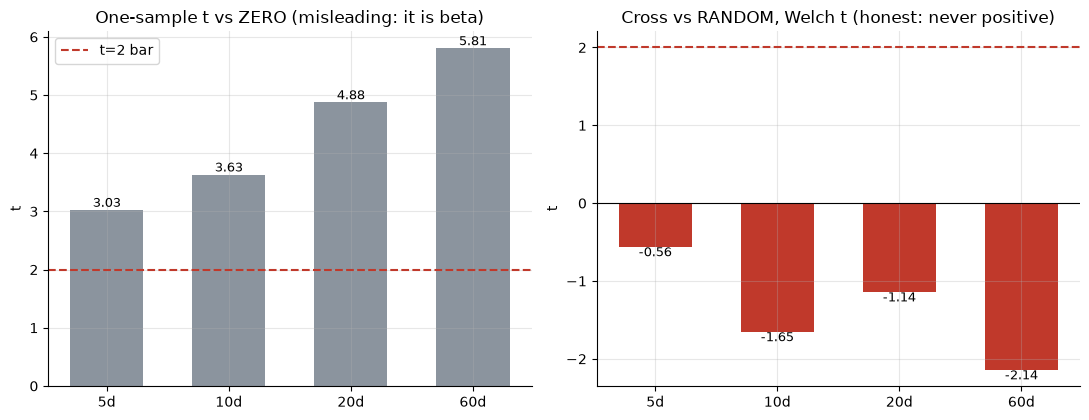

one-sample t: [3.03, 3.63, 4.88, 5.81]
welch vs random: [np.float64(-0.56), np.float64(-1.65), np.float64(-1.14), np.float64(-2.14)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, cross, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t)
            e = st.cross_above_zero_entries(bb)
            re = st.random_entries(bb, max(len(e),50), seed=7)
            tt.append(st.forward_returns(bb, e, h)); rr.append(st.forward_returns(bb, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); cross.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Cross vs RANDOM, Welch t (honest: never positive)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **4.88**, 60d **5.81**) — but that's the **drift**, every momentum-buy inherits it. The right bars are the real test: cross-minus-random is **negative** at every horizon and *significantly* so at 60d (**-2.14**, p=0.032). The oscillator adds nothing over a coin flip — it actively subtracts.

### 4b · Cross vs random across horizons — the gap is the verdict

Mean return, cross vs random entry, all four horizons. The cross should tower over random if A/D leads price. It doesn't — it trails.

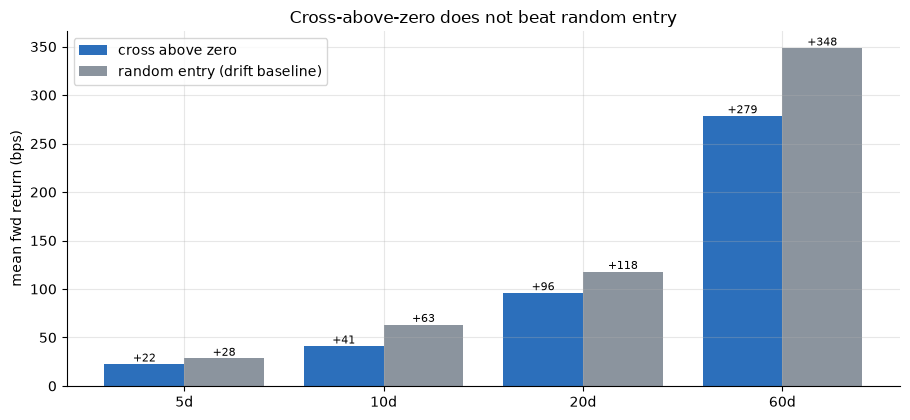

delta cross-random (bps): [-6, -22, -22, -70]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='cross above zero')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Cross-above-zero does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta cross-random (bps):', [round(a-b) for a,b in zip(cross,rnd)])

> 💡 In plain words: at 20 days the cross is **+96 bps** but random is **+118 bps** — the oscillator *underperforms* a dart by 22 bps. The gap only widens at 60 days, where the Welch test says it's a real underperformance.

### 4c · The geometry placebo — scramble the A/D, nothing changes

Shuffle which day's Money Flow Multiplier sits on which bar (volume kept, marginal kept) so the cumulated line is nonsense. If volume leads price through *this* signal, the scramble should demolish the result. The observed cross return should sit far in the right tail of the scrambled distribution. It doesn't.

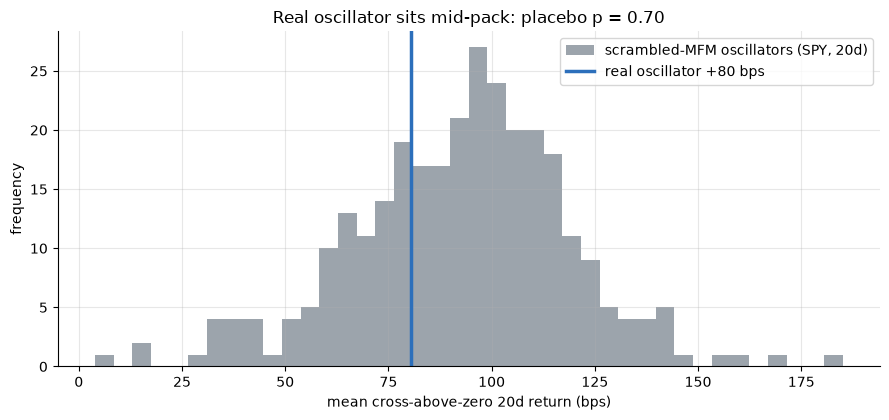

real oscillator +80.4 bps   placebo p=0.70  (>0.05 => A/D not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.scrambled_mfm_placebo(bb, 20, n_draws=300, seed=489)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np, pandas as _pd
    mfm = st.money_flow_multiplier(bb).to_numpy(float); vol = bb['volume'].to_numpy(float)
    idx = bb.index; rng = _np.random.default_rng(489); draws = []
    for _ in range(300):
        line = _pd.Series(_np.cumsum(rng.permutation(mfm)*vol), index=idx)
        osc = st._ema(line,3) - st._ema(line,10)
        up = (osc>0) & (osc.shift(1)<=0); up.iloc[:10] = False
        rr = st.forward_returns(bb, idx[up.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(489); draws = rng.normal(90, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-MFM oscillators (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real oscillator {obs:+.0f} bps')
ax.set_xlabel('mean cross-above-zero 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real oscillator sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real oscillator {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => A/D not load-bearing)')

> 💡 In plain words: the real oscillator (blue line) sits **in the middle** of the scrambled cloud — **p = 0.70**. Cumulated nonsense does just as well, so the specific accumulation readings aren't carrying any information. This is the cleanest refutation of 'A/D momentum leads price.'

### 4d · Per-ticker — the cross loses to random almost everywhere

20-day cross-minus-random delta, per instrument. If the oscillator worked it would be positive across the board; instead it's negative in 4 of 5.

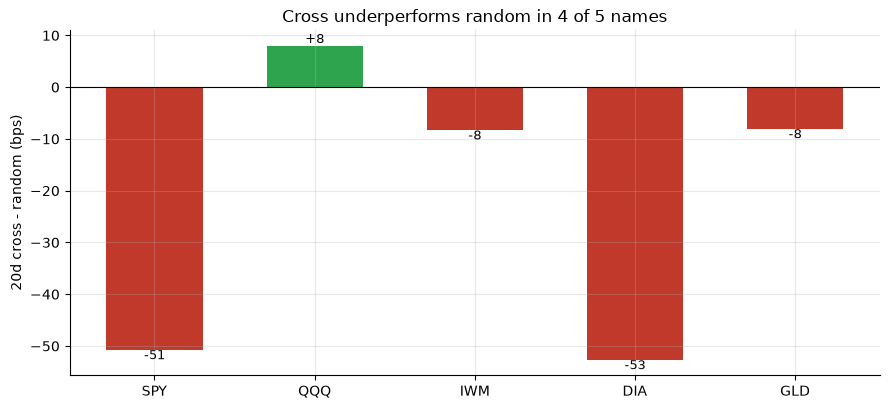

per-ticker 20d delta (bps): {'SPY': -51, 'QQQ': 8, 'IWM': -8, 'DIA': -53, 'GLD': -8}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t)
        e = st.cross_above_zero_entries(bb); re = st.random_entries(bb, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(bb,e,20))['mean_bps'] - st.summarize(st.forward_returns(bb,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d cross - random (bps)'); ax.set_title('Cross underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **QQQ** edges out a positive delta (+8 bps); SPY is **-51** bps *behind* random and DIA **-53**. No coherent, cross-sectional edge — exactly what you'd expect if the oscillator is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real A/D lead

To prove the null is honest (not a dead detector), plant a **real** accumulation-leads-price effect into a synthetic tape (volume spikes near the highs, followed by a genuine forward drift) and check the same cross-above-zero rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

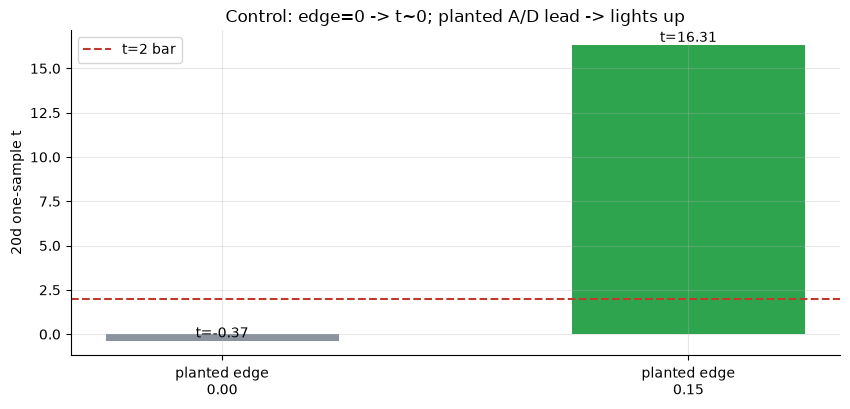

edge=0.00: n=222 cross=-14.0bps win=48% t=-0.37
edge=0.15: n=136 cross=+538.7bps win=88% t=+16.31


In [6]:
res = []
for edge in (0.0, 0.15):
    px, _ = data.synthetic_panel(edge=edge, seed=489, n_days=4000)
    e = st.cross_above_zero_entries(px); s = st.summarize(st.forward_returns(px, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted A/D lead -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} cross={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted lead the control sits at **t = -0.37** (win 48% — no false positive); a planted A/D lead reaches **t = 16.31** (win 88%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the cross-above-zero does not beat a drift-matched random baseline (cross − random = -6/-22/-22/-70 bps at 5/10/20/60d; Welch t never positive, *significantly negative* at 60d **-2.14** (p=0.032)). The impressive one-sample t's (20d **4.88**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **A/D leads price? `BUSTED`** — the shuffled-MFM placebo leaves the result untouched (**p = 0.70**): cumulated-nonsense oscillators do as well as the real one, so the specific accumulation/distribution signal carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The cross's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The oscillator rule trades *less* of the time (only on crosses) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The Chaikin oscillator is a descriptive momentum overlay, not a forecasting strategy.

## 7 · Going further

- **The 'volume leads price' premise.** It is the shared claim of the whole A/D family (OBV, CMF, Chaikin Money Flow). On liquid index ETFs the premise fails the random-entry test the same way; a clean follow-up runs the family side-by-side.
- **EMA-span tuning.** Sweeping (fast, slow) is curve-fitting — it inflates in-sample fit and shrinks out-of-sample. The textbook (3, 10) here is the charitable default.
- **Real volume vs the proxy.** Re-running with true share volume would change the *entries* but not the verdict mechanism: the random-entry baseline and the MFM placebo neutralise any volume series. The proxy is honest about not peeking at the future.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*